Saved: /maiziezhou_lab2/yuling/MouseSpinal/label_transfer/metric/0410_accuracy_heatmap_series17_fraction.pdf


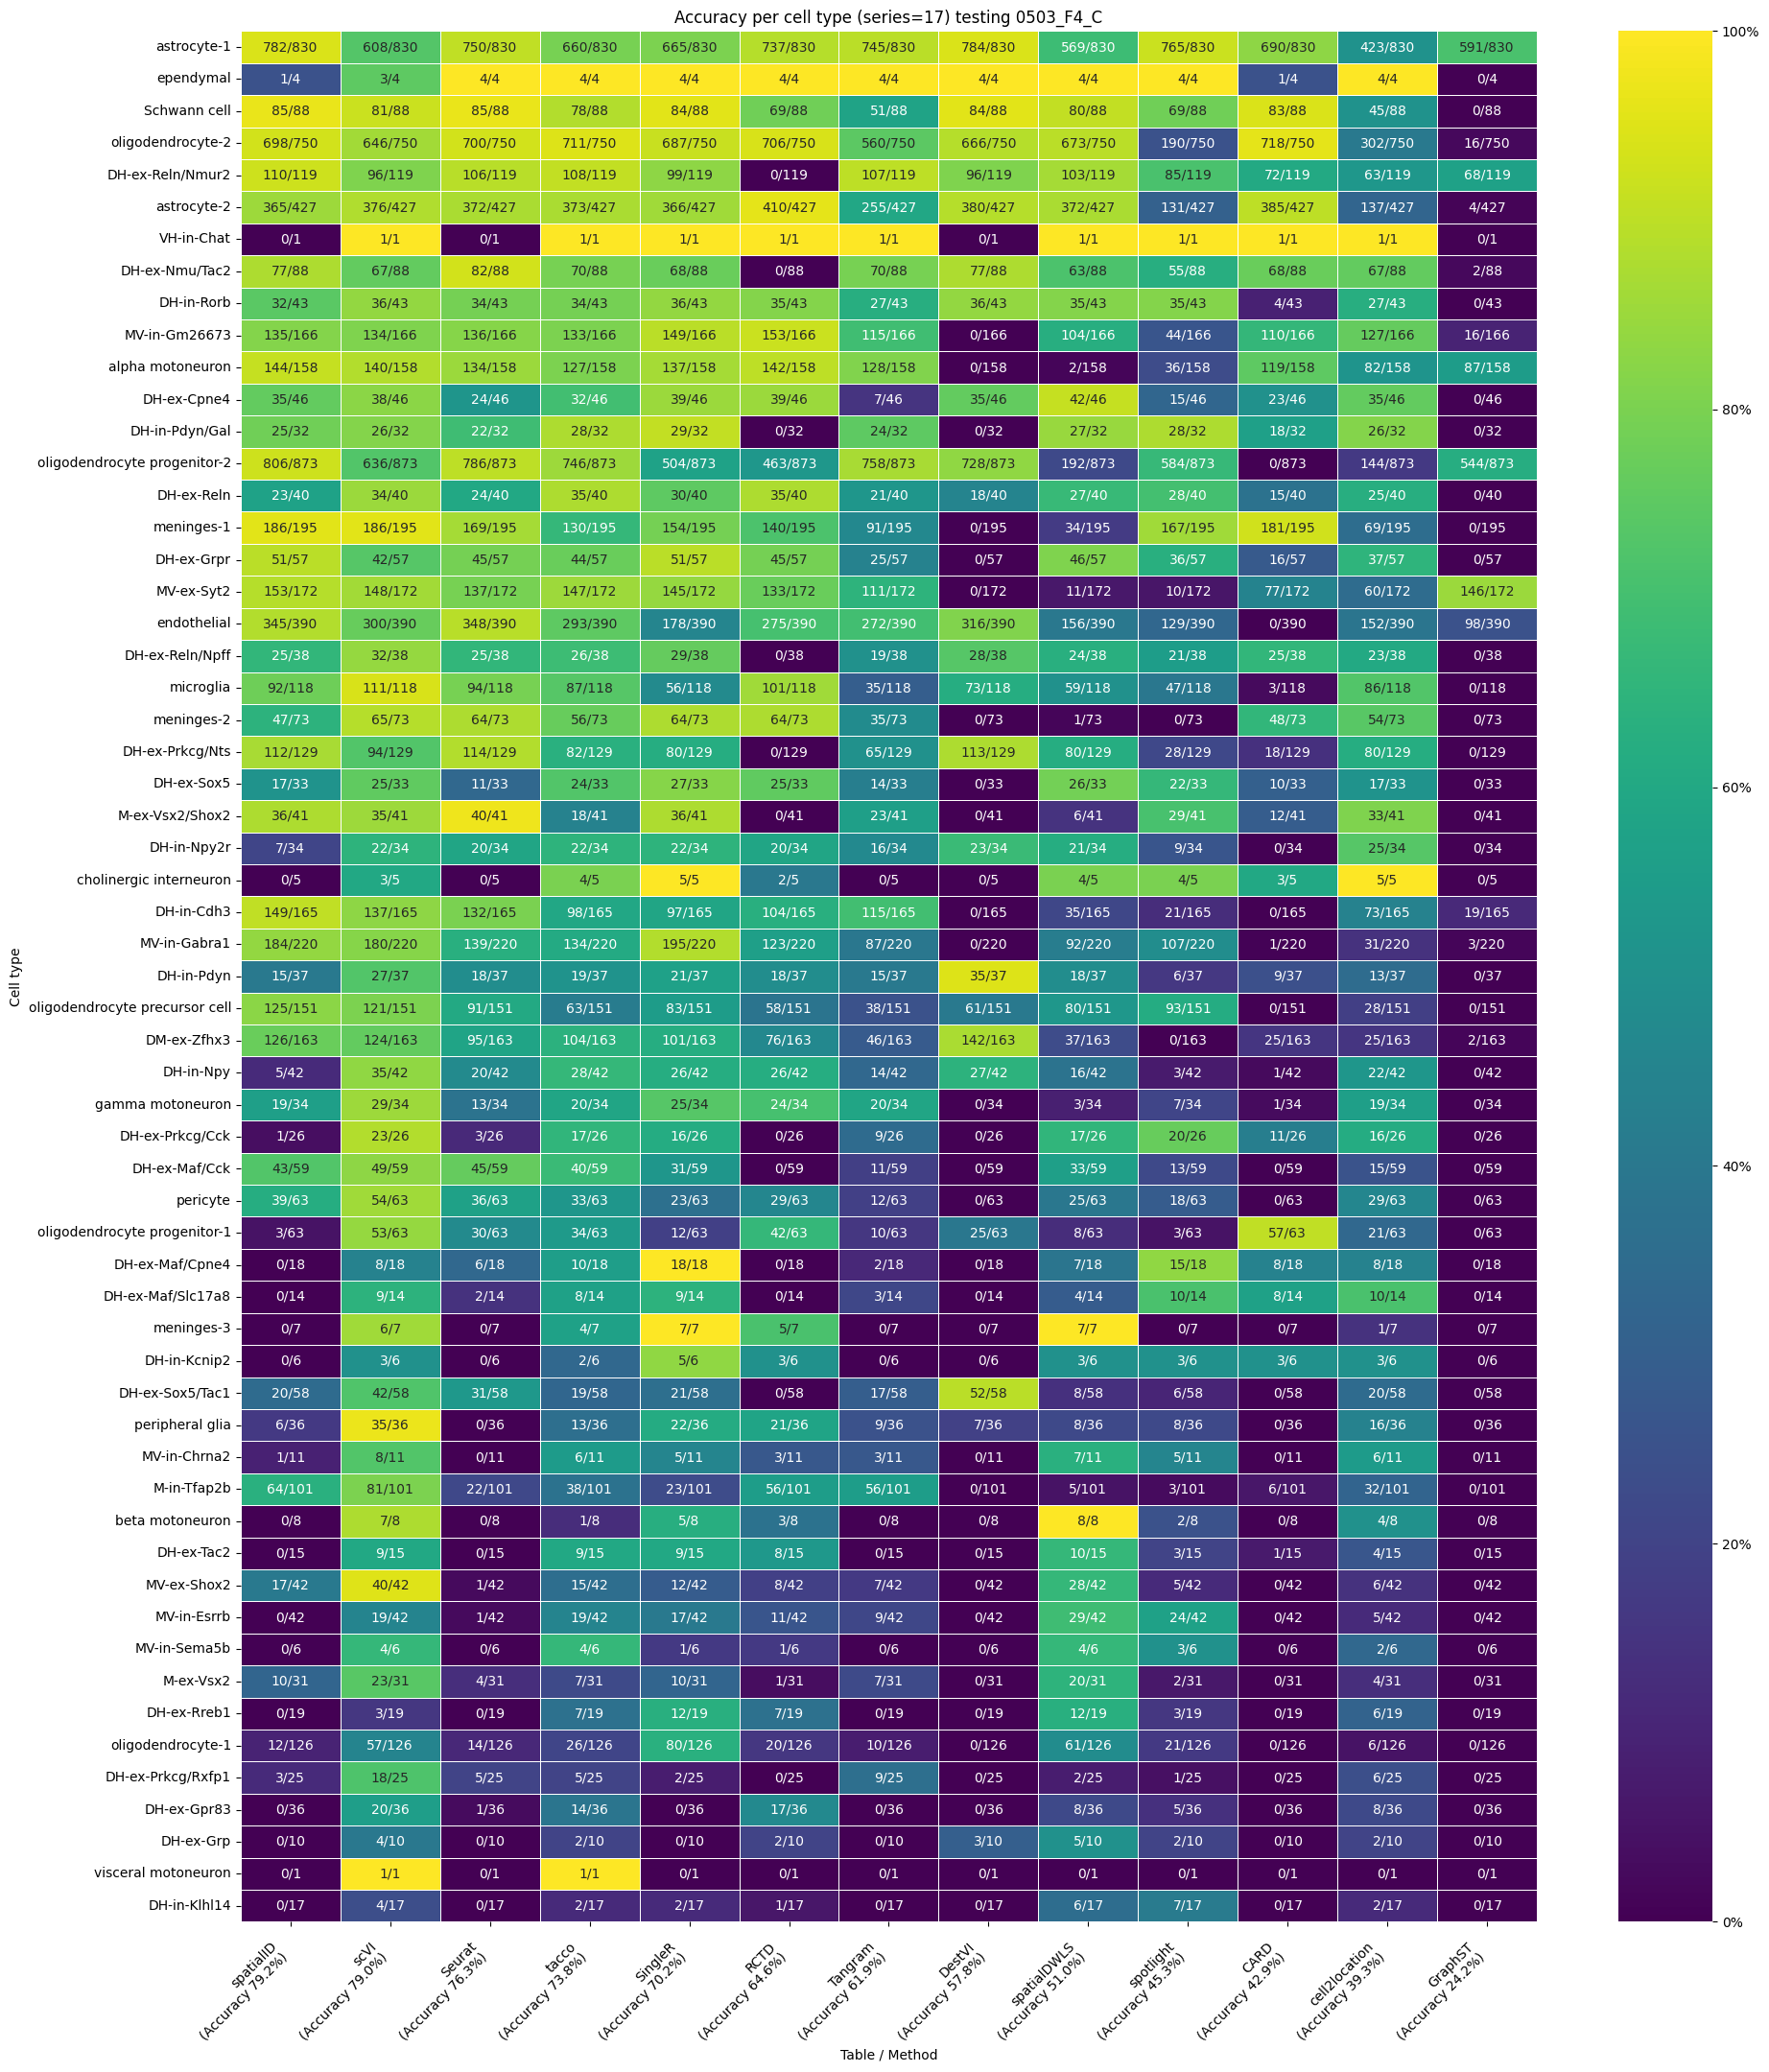

In [1]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
import os
from matplotlib.ticker import PercentFormatter

# PDF: TrueType (42) → text stays as real text in Adobe Illustrator (Type tool).
# Type 3 (default in many setups) is often outlined / harder to edit.
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42

base = "/maiziezhou_lab2/yuling/MouseSpinal/label_transfer"
paths = glob(os.path.join(base, "*/0503_F4_C_metric/per_celltype_accuracy_by_series.csv"))
# USE series=17 which has the largest reference volume 
series_to_use = 17   
acc_dfs = []      
ann_dfs = []

for p in paths:
    method = p.split("/label_transfer/")[1].split("/")[0]
    d = pd.read_csv(p)
    '''
    if 'cell2location' in method:
        series_to_use = 1
    else:
        series_to_use = 17
    '''
    if "series" in d.columns:
        d["series"] = pd.to_numeric(d["series"], errors="coerce")
        d = d[d["series"] == series_to_use]
    n_true_col = None
    for cand in ["n_true", "n_total", "total", "n", "n_samples", "n_obs"]:
        if cand in d.columns:
            n_true_col = cand
            break
    if n_true_col is None and "n_incorrect" in d.columns and "n_correct" in d.columns:
        d["__n_true__"] = d["n_correct"] + d["n_incorrect"]
        n_true_col = "__n_true__"
    if n_true_col is None or "n_correct" not in d.columns:
        print(f"[WARN] {method}: lack of n_true/n_correct, skip {p}")
        continue
    d = d[["cell_type", "n_correct", n_true_col]].copy()
    d = d.groupby("cell_type", as_index=False).sum()
    denom = d[n_true_col].replace(0, np.nan)
    acc_df = d[["cell_type"]].copy()
    acc_df[method] = (d["n_correct"] / denom).clip(0, 1)
    acc_dfs.append(acc_df)
    ncor = d["n_correct"].fillna(0).astype("Int64")
    ntot = d[n_true_col].fillna(0).astype("Int64")
    ann_df = d[["cell_type"]].copy()
    ann_df[method] = ncor.astype(str) + "/" + ntot.astype(str)
    ann_dfs.append(ann_df)
mat = None
for df in acc_dfs:
    mat = df if mat is None else mat.merge(df, on="cell_type", how="outer")

ann = None
for df in ann_dfs:
    ann = df if ann is None else ann.merge(df, on="cell_type", how="outer")

if mat is None or mat.empty:
    raise RuntimeError("no data")

mat = mat.set_index("cell_type").astype(float)
mat = mat.fillna(0.0)

ann = ann.set_index("cell_type")

ann = ann.reindex(index=mat.index, columns=mat.columns).fillna("0/0")
ann = ann.reindex(index=mat.index, columns=mat.columns)
row_order = mat.mean(axis=1).sort_values(ascending=False).index
mat = mat.loc[row_order]
ann = ann.loc[row_order]

col_order = mat.mean(axis=0).sort_values(ascending=False).index
mat = mat[col_order]
ann = ann[col_order]
def split_frac(s):
    if isinstance(s, str) and "/" in s:
        a, b = s.split("/")
        try:
            return int(a), int(b)
        except:
            return 0, 0
    return 0, 0
nc_mat = ann.applymap(lambda x: split_frac(x)[0]).astype(int)  # TP
nt_mat = ann.applymap(lambda x: split_frac(x)[1]).astype(int)  
col_nc = nc_mat.sum(axis=0)
col_nt = nt_mat.sum(axis=0).replace(0, np.nan)
col_micro = (col_nc / col_nt).fillna(0.0)

col_order = col_micro.sort_values(ascending=False).index
mat = mat[col_order]
ann = ann[col_order]
col_micro = col_micro[col_order]
plt.figure(figsize=(1.2*mat.shape[1] + 4, 0.3*mat.shape[0] + 4))
ax = sns.heatmap(
    mat, vmin=0, vmax=1, cmap="viridis",
    annot=ann.values, fmt="",
    linewidths=0.5, linecolor="white",
    cbar_kws={"format": PercentFormatter(xmax=1)}
)
import re
def split_frac(s):
    if isinstance(s, str) and "/" in s:
        a,b = s.split("/")
        try:
            return int(a), int(b)
        except:
            return 0, 0
    return 0, 0
nc_mat = ann.applymap(lambda x: split_frac(x)[0]).astype(int)
nt_mat = ann.applymap(lambda x: split_frac(x)[1]).astype(int)

col_nc = nc_mat.sum(axis=0)      
col_nt = nt_mat.sum(axis=0)      
col_micro = (col_nc / col_nt.replace(0, np.nan)).fillna(0.0)
row_nc = nc_mat.sum(axis=1)
row_nt = nt_mat.sum(axis=1)
row_micro = (row_nc / row_nt.replace(0, np.nan)).fillna(0.0)
xticks = [f"{name}\n(Accuracy {col_micro[name]:.1%})" for name in mat.columns]
yticks = [f"{name}  (Accuracy {row_micro[name]:.1%})" for name in mat.index]

ax.set_xticklabels(xticks, rotation=45, ha="right")
#ax.set_yticklabels(yticks, rotation=0, va="center")
ax.tick_params(axis='x', which='major', pad=10)

ax.set_xlabel("Table / Method")
ax.set_ylabel("Cell type")
ax.set_title(f"Accuracy per cell type (series={series_to_use}) testing 0503_F4_C")
ax.collections[0].colorbar.ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))

plt.tight_layout()
os.makedirs(os.path.join(base, "metric"), exist_ok=True)
_out_pdf = os.path.join(base, "metric", f"0410_accuracy_heatmap_series{series_to_use}_fraction.pdf")
plt.savefig(_out_pdf, format="pdf", bbox_inches="tight")
print(f"Saved: {_out_pdf}")
plt.show()
mat.to_csv(os.path.join(base, "metric", f"1022_accuracy_matrix_series{series_to_use}.csv"))
ann.to_csv(os.path.join(base, "metric", f"1022_accuracy_matrix_series{series_to_use}_fraction.csv"))
